<a href="https://colab.research.google.com/github/shubhes/DeepReservoir/blob/main/reservoir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

  Using cached torch-2.6.0-cp311-cp311-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached filelock-3.17.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.5-py3-none-any.whl.metadata (2.6 kB)
  Using cached fsspec-2025.2.0-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Usin

# **DQN agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode - Agent Based State Propagation**

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.69     |
|    n_updates        | 560014   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18672    |
|    fps              | 515      |
|    time_elapsed     | 4345     |
|    total_timesteps  | 2240640  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 2.26     |
|    n_updates        | 560134   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18676    |
|   

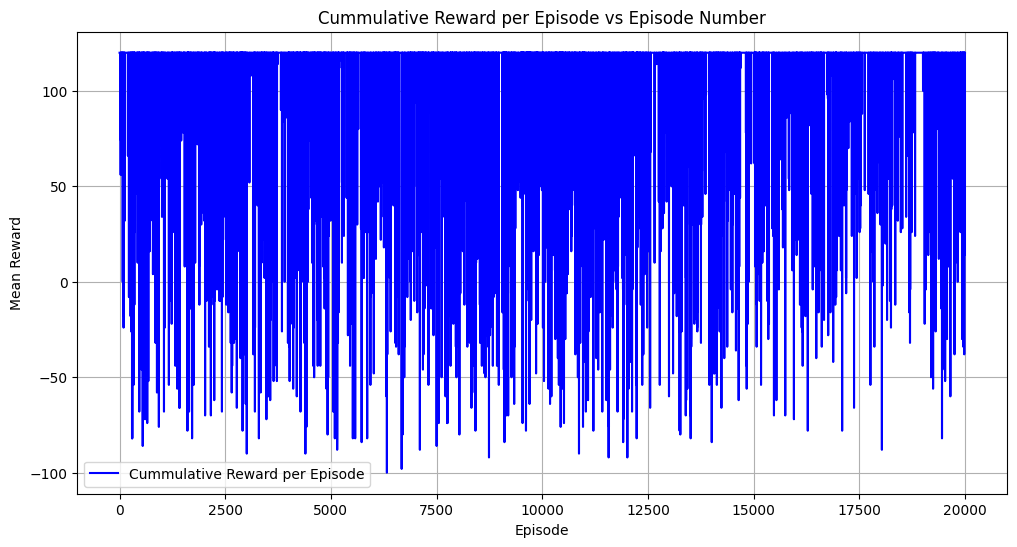

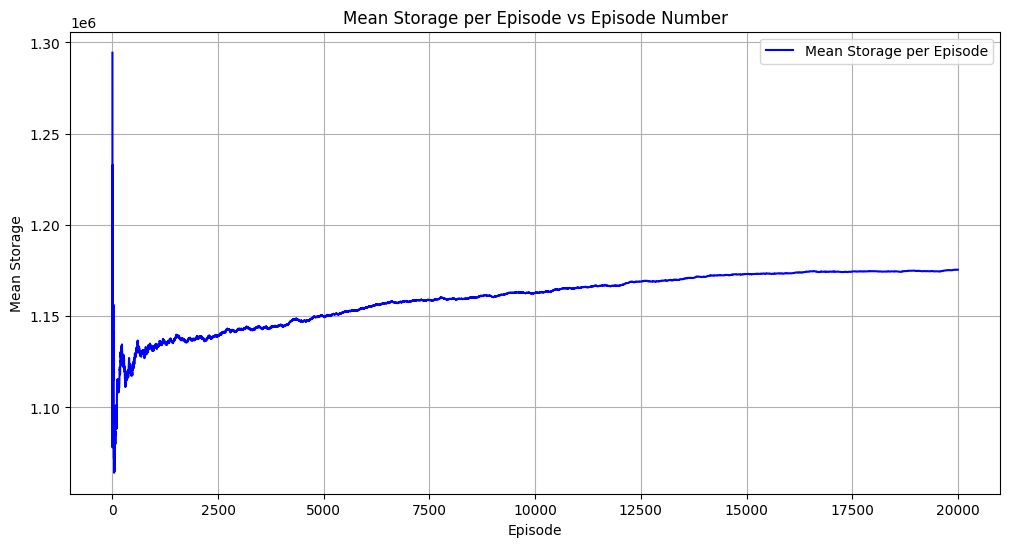

Training complete. Model and reward plot saved.


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits (scaled values will be calculated later)
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
release_cfs_discrete = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]  # More discrete release values
release_af = [r * 1.98211 for r in release_cfs_discrete]  # Convert cfs to acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, release_af, min_storage_af,max_storage_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.release_af = release_af
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history=[]
        self.episode_reward=[]
        self.storage_history=[]
        self.mean_storage_history = []


        # Define action space and observation space
        self.action_space = Discrete(len(self.release_af))  # Actions: scaled release values
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()

        # Set the storage to the value corresponding to the start of the episode
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # Mapping action index to scaled release value
        release_af_value = self.release_af[action]
        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]

        # Updating storage with inflow, evaporation, and release (all in scaled values)
        self.current_storage += inflow_af - evaporation_af - release_af_value
        # print(f"Step {self.current_step}: Actual Storage: {self.data[self.current_step, 0]}, Current Storage: {self.current_storage}, Actual Release: {self.data[self.current_step, 3]}, Predicted Release: {release_af_value}")

        # Reward calculation (scaled storage range: 0 to 1)
        if self.min_storage_af<= self.current_storage <= self.max_storage_af:
            reward = 1 # Positive reward for staying within bounds
            # reward = 1- (abs(self.current_storage - target_storage_af) / target_storage_af)  # Positive reward for staying within bounds
        else:
            reward = -1  # Negative reward for going out of bounds

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        # Recording mean rewards after each episode
        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, release_af, min_storage_af,max_storage_af, episode_length)

# Initialize DQN model
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,
    batch_size=32,
    train_freq=4,
    buffer_size=100000,
    exploration_fraction=0.3,
    exploration_final_eps=0.01,
    target_update_interval=1000,
)

# Training the model
n_episodes = 20000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save the model
model.save("dqn_reservoir_agent")

# Plot mean rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cummulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("Cummulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cummulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

pd.DataFrame(env.episode_reward).to_csv("cummulative_reward_per_episode.csv", index=False)
print("Training complete. Model and reward plot saved.")

506159.0
Prediction completed and saved to CSV files.


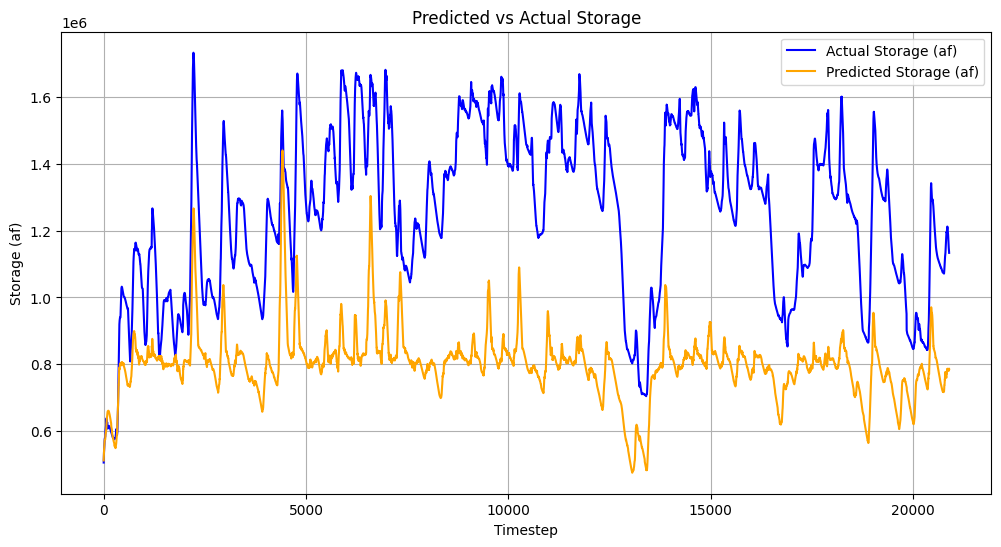

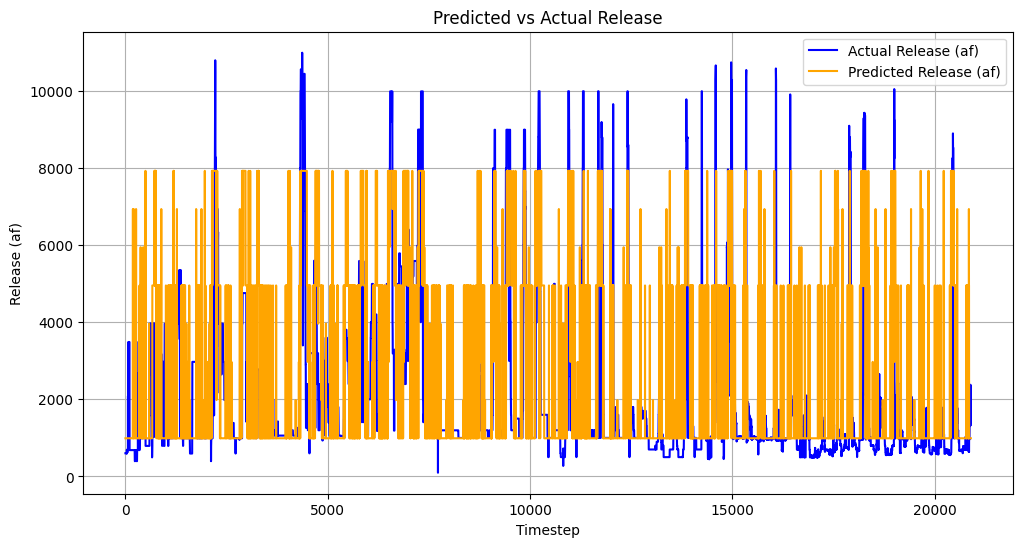

In [ ]:
# Load the trained DQN agent
model = DQN.load("dqn_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0,0]
print(current_storage)

# Perform predictions
for i in range(len(dataset)):
    # Get the observation from the dataset (without scaling)
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]])
    # Predict the action using the trained agent
    action, _ = model.predict(observation)

    # Map the action to the corresponding release value in acre-feet
    predicted_release_af = release_af[action]

    # Extract inflow and evaporation directly from the dataset (unscaled)
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage += inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset
    # print(f"Step {i}: Observation: {observation}, Predicted Release: {predicted_release_af}, Current Storage: {current_storage}")


# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

# Save the results to CSV files
predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)
pd.DataFrame(dataset).to_csv("complete_dataset.csv", index=False)

print("Prediction completed and saved to CSV files.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

# **TD3 agent**

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 102      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 39       |
|    time_elapsed    | 12       |
|    total_timesteps | 480      |
| train/             |          |
|    actor_loss      | 1.63e+04 |
|    critic_loss     | 1.17e+06 |
|    learning_rate   | 0.001    |
|    n_updates       | 379      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 111      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 35       |
|    time_elapsed    | 26       |
|    total_timesteps | 960      |
| train/             |          |
|    actor_loss      | 1.6e+04  |
|    critic_loss     |

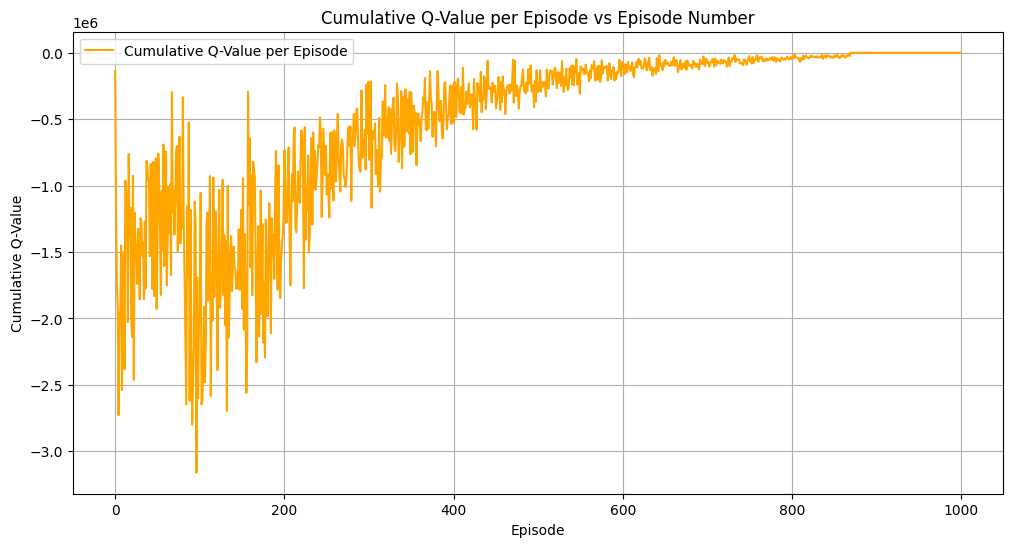

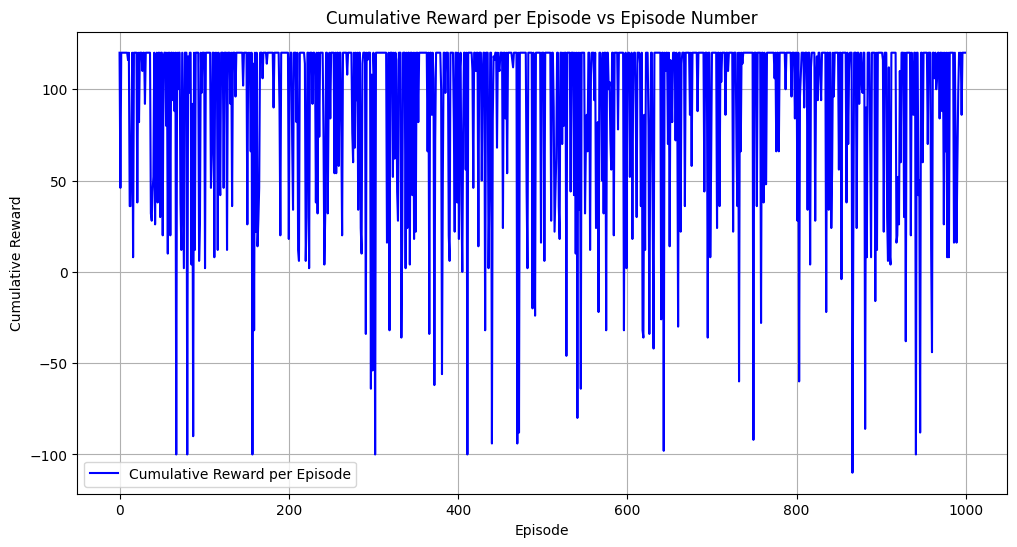

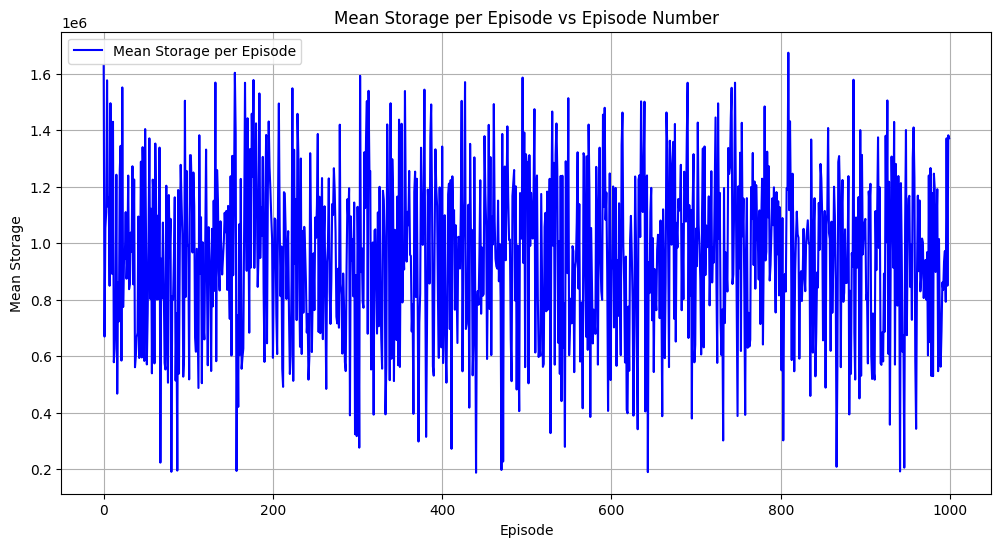

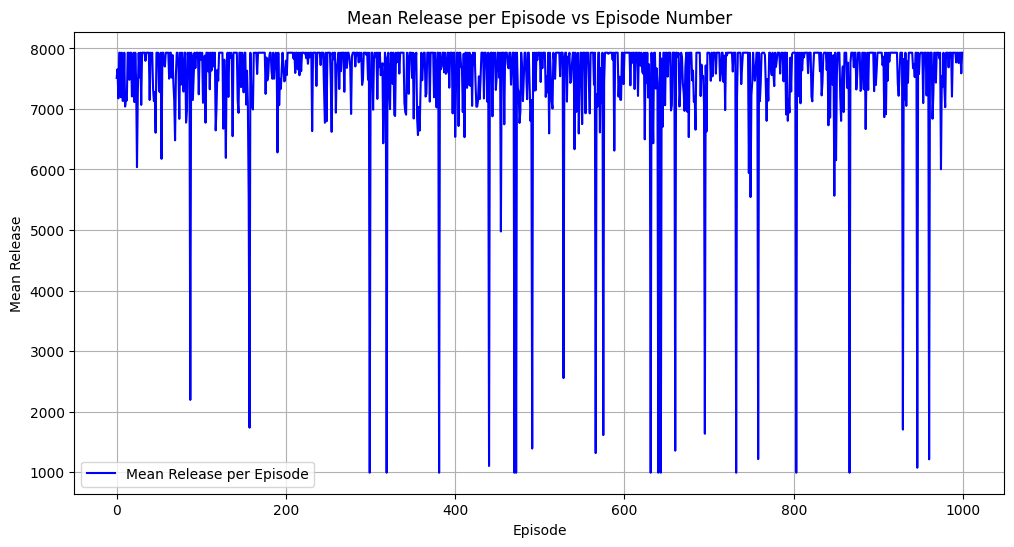

Training complete. Model, Q values, release, and reward plots saved.


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Split dataset
train_data = dataset[:18000]  # First 18,000 samples for training
test_data = dataset[18000:]   # Remaining samples for testing

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, td3_model):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.td3_model = td3_model  # To compute Q-values
        self.reward_history, self.episode_reward = [], []
        self.storage_history, self.mean_storage_history = [], []
        self.q_values, self.cumulative_q_values = [], []
        self.release_history, self.mean_release_history = [], []
        self.current_step, self.episode_step_count = 0, 0

        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)  # Random episode start
        self.episode_step_count = 0
        self.reward_history.clear()
        self.q_values.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        normalized_release = (action[0] + 1) / 2
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

        # Compute Reward
        reward = -abs(self.current_storage - (self.max_storage_af + self.min_storage_af) / 2) / self.max_storage_af

        # Compute Q-value
        obs_tensor = th.tensor(self._get_observation(), dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        action_tensor = th.tensor(action, dtype=th.float32).unsqueeze(0).to(self.td3_model.device)
        with th.no_grad():
            q_value = self.td3_model.critic(obs_tensor, action_tensor)[0].mean().item()
        self.q_values.append(q_value)

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.episode_step_count >= self.episode_length
        done = self.current_step >= len(self.data) or (self.episode_step_count >= self.episode_length)

        if done:
            self.episode_reward.append(sum(self.reward_history))
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        return self._get_observation() if not done else np.zeros(3), reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(train_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, None)

# Initialize model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.2 * np.ones(n_actions))
model = TD3("MlpPolicy", env, policy_kwargs={"net_arch": [400, 300]}, action_noise=action_noise, verbose=1)

# Pass the TD3 model to the environment
env.td3_model = model

# Train the model
n_episodes = 1000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

# Save cumulative Q-values to CSV
pd.DataFrame(env.cumulative_q_values, columns=["Cumulative Q-Value"]).to_csv("cumulative_q_values_per_episode.csv", index=False)

# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative Q-values per episode
plt.figure(figsize=(12, 6))
plt.plot(env.cumulative_q_values, label="Cumulative Q-Value per Episode", color="orange")
plt.xlabel("Episode")
plt.ylabel("Cumulative Q-Value")
plt.title("Cumulative Q-Value per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_q_values_per_episode.png")
plt.show()

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model, Q values, release, and reward plots saved.")

# Load trained model
model = TD3.load("td3_reservoir_agent")

# Set up test environment
test_env = ReservoirEnv(test_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length, model)

# Lists to store results
predicted_storage, actual_storage = [], []
predicted_release, actual_release = [], []

# Perform predictions on sampled 120-day episodes from test data
num_episodes = len(test_data) // episode_length  # Maximum possible episodes

for _ in range(num_episodes):
    obs, _ = test_env.reset()

    for _ in range(episode_length):
        action, _ = model.predict(obs, deterministic=True)  # Use deterministic actions during testing
        obs, reward, done, _, _ = test_env.step(action)

        # Store results
        predicted_storage.append(obs[0])  # Predicted storage (first element of obs)

        # Access the release value after calling step
        normalized_release = (action[0] + 1) / 2
        predicted_release_af = test_env.min_release_af + normalized_release * (test_env.max_release_af - test_env.min_release_af) # Calculate predicted release
        predicted_release.append(predicted_release_af)

        actual_storage.append(test_env.data[test_env.current_step, 0])  # True storage from dataset
        actual_release.append(test_env.data[test_env.current_step, 3])  # True release from dataset

        if done:
            break  # End episode if max steps reached

# Save results
pd.DataFrame({"Predicted Storage (af)": predicted_storage, "Actual Storage (af)": actual_storage}).to_csv("predicted_vs_actual_storage.csv", index=False)
pd.DataFrame({"Predicted Release (af)": predicted_release, "Actual Release (af)": actual_release}).to_csv("predicted_vs_actual_release.csv", index=False)

print("Testing complete.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_storage.png")
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_release.png")
plt.show()

# # Load trained model
# model = TD3.load("td3_reservoir_agent")

# # Set up variables for predictions
# predicted_storage, actual_storage = [], []
# predicted_release, actual_release = [], []

# # Set up testing parameters
# episode_length = 120
# num_episodes = len(test_data) // episode_length  # Maximum number of episodes possible

# # Perform predictions on sampled 120-day episodes from test data
# for _ in range(num_episodes):
#     start_idx = np.random.randint(0, len(test_data) - episode_length)
#     current_storage = test_data[start_idx, 0]

#     for i in range(start_idx, start_idx + episode_length):
#         observation = np.array([current_storage, test_data[i, 1], test_data[i, 2]], dtype=np.float32)

#         action, _ = model.predict(observation)
#         normalized_release = (action[0] + 1) / 2
#         predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

#         inflow_af = test_data[i, 2]
#         evaporation_af = test_data[i, 1]
#         current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

#         predicted_storage.append(current_storage)
#         predicted_release.append(predicted_release_af)
#         actual_storage.append(test_data[i, 0])
#         actual_release.append(test_data[i, 3])

# # Save results
# pd.DataFrame({"Predicted Storage (af)": predicted_storage, "Actual Storage (af)": actual_storage}).to_csv("predicted_vs_actual_storage.csv", index=False)
# pd.DataFrame({"Predicted Release (af)": predicted_release, "Actual Release (af)": actual_release}).to_csv("predicted_vs_actual_release.csv", index=False)

# print("Testing complete.")

# # Plot Predicted vs Actual Storage
# plt.figure(figsize=(12, 6))
# plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
# plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
# plt.xlabel("Timestep")
# plt.ylabel("Storage (af)")
# plt.title("Predicted vs Actual Storage")
# plt.legend()
# plt.grid()
# plt.savefig("Predicted vs Actual Storage.png")
# plt.show()

# # Plot Predicted vs Actual Release
# plt.figure(figsize=(12, 6))
# plt.plot(actual_release, label="Actual Release (af)", color="blue")
# plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
# plt.xlabel("Timestep")
# plt.ylabel("Release (af)")
# plt.title("Predicted vs Actual Release")
# plt.legend()
# plt.grid()
# plt.savefig("Predicted vs Actual Release.png")
# plt.show()

# **PPO Agent**

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 120      |
|    ep_rew_mean     | 120      |
| time/              |          |
|    fps             | 2085     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 120          |
|    ep_rew_mean          | 120          |
| time/                   |              |
|    fps                  | 1464         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0017773695 |
|    clip_fraction        | 0.00161      |
|    clip_range           | 0.2          |
|    en

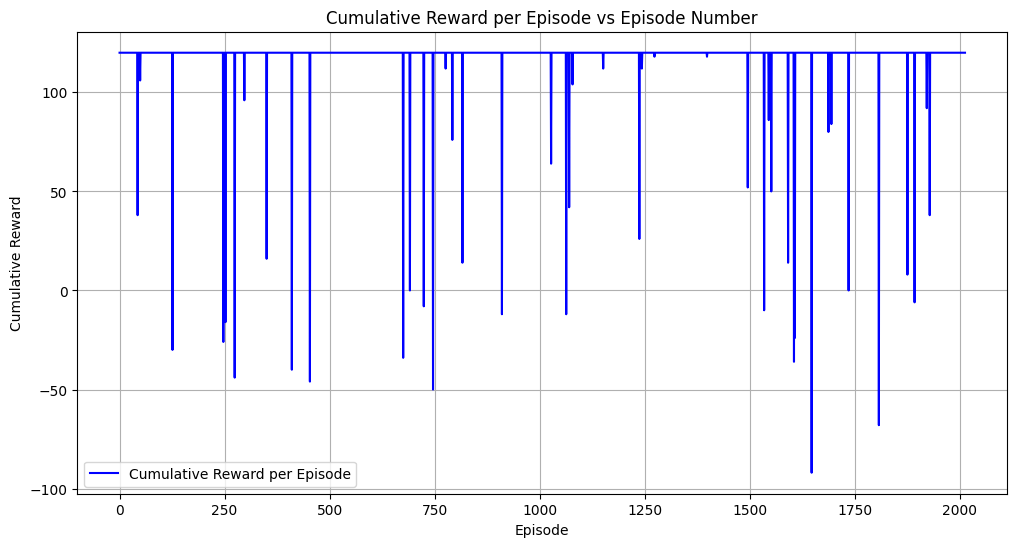

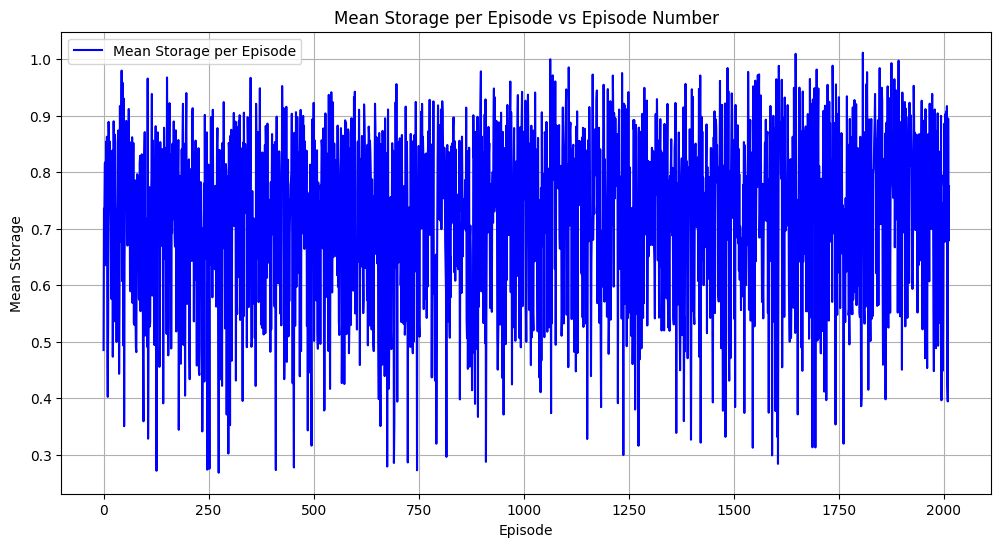

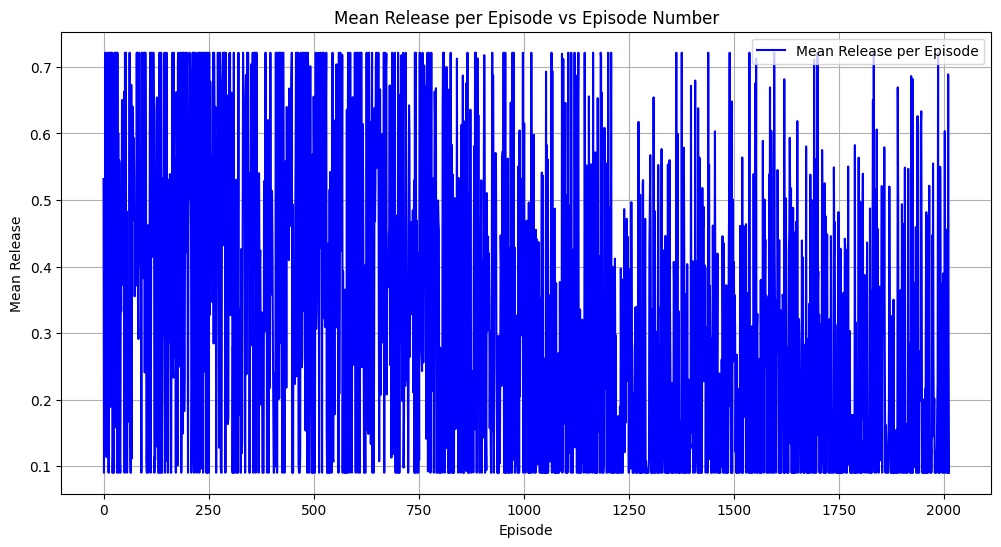

Training complete. Model, Storage, Release, and Reward plots saved.
Testing complete.


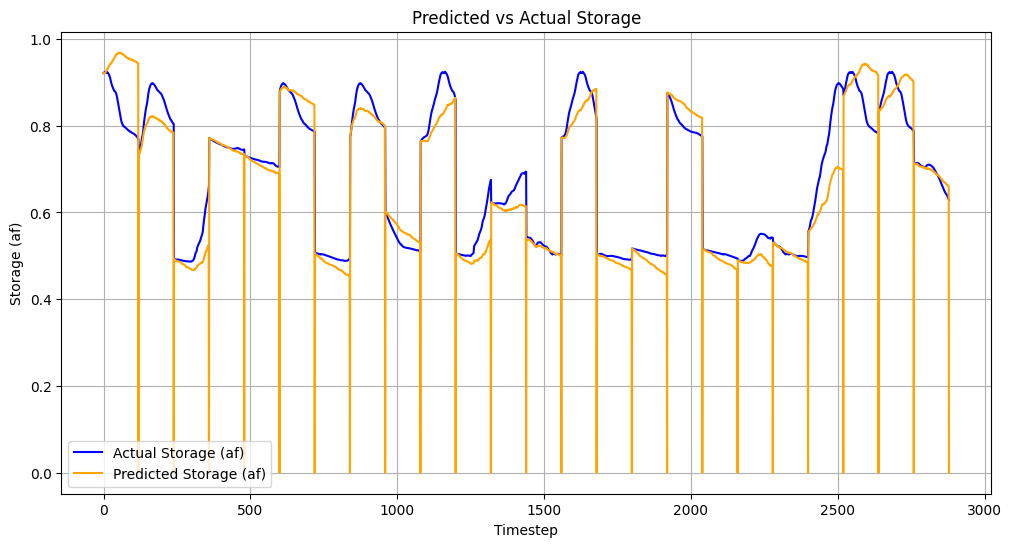

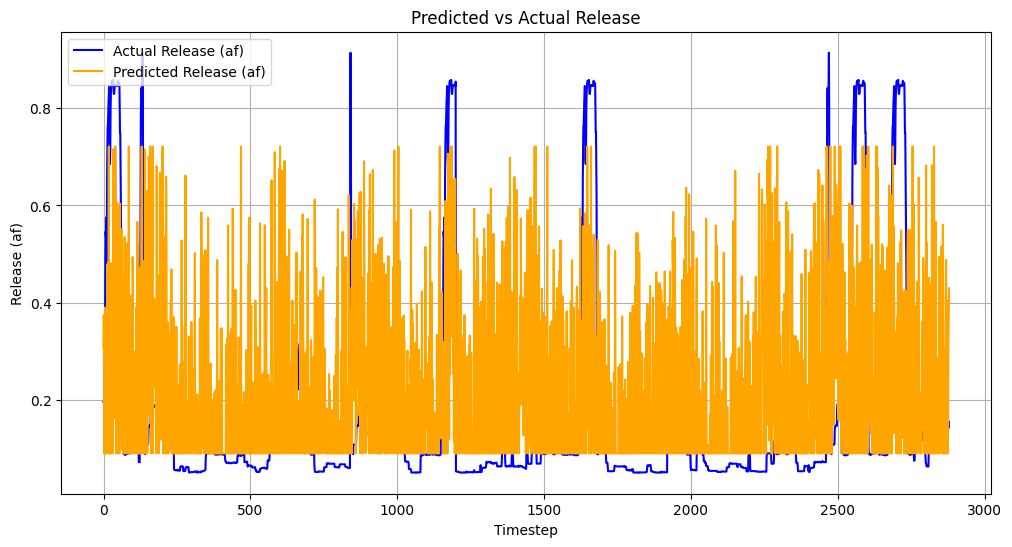

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import PPO
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000/1731750
max_storage_af = 1731750/1731750
min_release_af = (500 * 1.98211)/(5546*1.98211)  # Minimum release in acre-feet
max_release_af = (4000 * 1.98211)/(5546*1.98211)  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage/1731750, evaporation/183, (inflow_cfs* 1.98211)/(15398*1.98211), (release_cfs * 1.98211)/(5546 * 1.98211)))

# Split dataset
train_data = dataset[:18000]  # First 18,000 samples for training
test_data = dataset[18000:]   # Remaining samples for testing

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.reward_history, self.episode_reward = [], []
        self.storage_history, self.mean_storage_history = [], []
        self.release_history, self.mean_release_history = [], []
        self.current_step, self.episode_step_count = 0, 0

        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([0,0,0]),
                                     high=np.array([1,1,1]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)  # Random episode start
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        normalized_release = (action[0] + 1) / 2
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage = self.current_storage*1731750+(inflow_af*15398 - evaporation_af*183 - release_af_value*5546)
        self.current_storage = self.current_storage/1731750

        # Compute Reward
        if self.min_storage_af <= self.current_storage <= self.max_storage_af:
            reward = 1
        else:
            reward = -1

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count >= self.episode_length)

        if done:
            self.episode_reward.append(sum(self.reward_history))
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        return self._get_observation() if not done else np.zeros(3), reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(train_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Initialize model
model = PPO("MlpPolicy", env,  verbose=1)

# Train the model
n_episodes = 2000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save model
model.save("ppo_reservoir_agent")

# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model, Storage, Release, and Reward plots saved.")

# Load trained model
model = PPO.load("ppo_reservoir_agent")

# Set up test environment
test_env = ReservoirEnv(test_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Lists to store results
predicted_storage, actual_storage = [], []
predicted_release, actual_release = [], []

# Perform predictions on sampled 120-day episodes from test data
num_episodes = len(test_data) // episode_length  # Maximum possible episodes

for _ in range(num_episodes):
    obs, _ = test_env.reset()

    for _ in range(episode_length):
        action, _ = model.predict(obs)  # Use deterministic actions during testing
        obs, reward, done, _, _ = test_env.step(action)

        # Store results
        predicted_storage.append(obs[0])  # Predicted storage (first element of obs)

        # Access the release value after calling step
        normalized_release = (action[0] + 1) / 2
        predicted_release_af = test_env.min_release_af + normalized_release * (test_env.max_release_af - test_env.min_release_af)
        predicted_release.append(predicted_release_af)

        actual_storage.append(test_env.data[test_env.current_step, 0])  # True storage from dataset
        actual_release.append(test_env.data[test_env.current_step, 3])  # True release from dataset

        if done:
            break  # End episode if max steps reached

# Save results
pd.DataFrame({"Predicted Storage (af)": predicted_storage, "Actual Storage (af)": actual_storage}).to_csv("predicted_vs_actual_storage.csv", index=False)
pd.DataFrame({"Predicted Release (af)": predicted_release, "Actual Release (af)": actual_release}).to_csv("predicted_vs_actual_release.csv", index=False)

print("Testing complete.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_storage.png")
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_release.png")
plt.show()

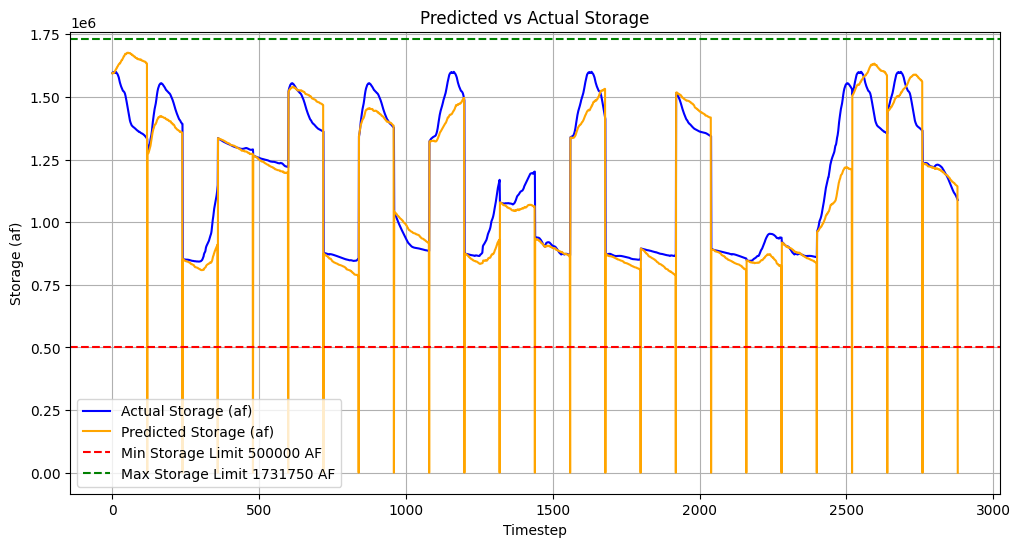

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('/content/predicted_vs_actual_storage.csv')

# Define columns to plot
actual_storage = "Actual Storage (af) Rescaled"  # Change to the actual column name
predicted_storage = "Predicted Storage (af) Rescaled"  # Change to the actual column name

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(df[actual_storage], label="Actual Storage (af)", color="blue")
plt.plot(df[predicted_storage], label="Predicted Storage (af)", color="orange")
plt.axhline(y=500000, color="r", linestyle="--", label=f"Min Storage Limit {500000} AF")
plt.axhline(y=1731750, color="g", linestyle="--", label=f"Max Storage Limit {1731750} AF")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_storage_rescaled.png")
plt.show()

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000/1731750
max_storage_af = 1731750/1731750
min_release_af = (500 * 1.98211)/(5546*1.98211)  # Minimum release in acre-feet
max_release_af = (4000 * 1.98211)/(5546*1.98211)  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage/1731750, evaporation/183, (inflow_cfs* 1.98211)/(15398*1.98211), (release_cfs * 1.98211)/(5546 * 1.98211)))

# Split dataset
train_data = dataset[:18000]  # First 18,000 samples for training
test_data = dataset[18000:]   # Remaining samples for testing

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.reward_history, self.episode_reward = [], []
        self.storage_history, self.mean_storage_history = [], []
        self.release_history, self.mean_release_history = [], []
        self.current_step, self.episode_step_count = 0, 0

        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([0,0,0]),
                                     high=np.array([1,1,1]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)  # Random episode start
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        normalized_release = (action[0] + 1) / 2
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage = self.current_storage*1731750+(inflow_af*15398 - evaporation_af*183 - release_af_value*5546)
        self.current_storage = self.current_storage/1731750

        # Compute Reward
        if self.min_storage_af <= self.current_storage <= self.max_storage_af:
            reward = 1
        else:
            reward = -1

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count >= self.episode_length)

        if done:
            self.episode_reward.append(sum(self.reward_history))
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        return self._get_observation() if not done else np.zeros(3), reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(train_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Initialize model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3("MlpPolicy", env, action_noise=action_noise, verbose=1)

# Train the model
n_episodes = 2000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

# Save cumulative reward values to CSV
pd.DataFrame(env.episode_reward).to_csv("cumulative_reward_per_episode.csv", index=False)

# Plot cumulative rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cumulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cumulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

# Plot mean release per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_release_history, label="Mean Release per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Release")
plt.title("Mean Release per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_release_per_episode.png")
plt.show()

print("Training complete. Model, Storage, Release, and Reward plots saved.")

# Load trained model
model = TD3.load("td3_reservoir_agent")

# Set up test environment
test_env = ReservoirEnv(test_data, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Lists to store results
predicted_storage, actual_storage = [], []
predicted_release, actual_release = [], []

# Perform predictions on sampled 120-day episodes from test data
num_episodes = len(test_data) // episode_length  # Maximum possible episodes

for _ in range(num_episodes):
    obs, _ = test_env.reset()

    for _ in range(episode_length):
        action, _ = model.predict(obs)  # Use deterministic actions during testing
        obs, reward, done, _, _ = test_env.step(action)

        # Store results
        predicted_storage.append(obs[0])  # Predicted storage (first element of obs)

        # Access the release value after calling step
        normalized_release = (action[0] + 1) / 2
        predicted_release_af = test_env.min_release_af + normalized_release * (test_env.max_release_af - test_env.min_release_af)
        predicted_release.append(predicted_release_af)

        actual_storage.append(test_env.data[test_env.current_step, 0])  # True storage from dataset
        actual_release.append(test_env.data[test_env.current_step, 3])  # True release from dataset

        if done:
            break  # End episode if max steps reached

# Save results
pd.DataFrame({"Predicted Storage (af)": predicted_storage, "Actual Storage (af)": actual_storage}).to_csv("predicted_vs_actual_storage.csv", index=False)
pd.DataFrame({"Predicted Release (af)": predicted_release, "Actual Release (af)": actual_release}).to_csv("predicted_vs_actual_release.csv", index=False)

print("Testing complete.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_storage.png")
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.savefig("test_predicted_vs_actual_release.png")
plt.show()